# Structural robustness of mammalian transcription factor networks reveals plasticity across development

## Mouse Analysis

### Imports

In [34]:
import os
import pandas as pd
from io import BytesIO
import networkx as nx
from PIL import Image
import inspect
import numpy as np
import seaborn as sns
import networkx as nx
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from itertools import chain
import re
import freyrelab
from freyrelab.regnets.regnet import RegNet
import time

### Extracción de las redes

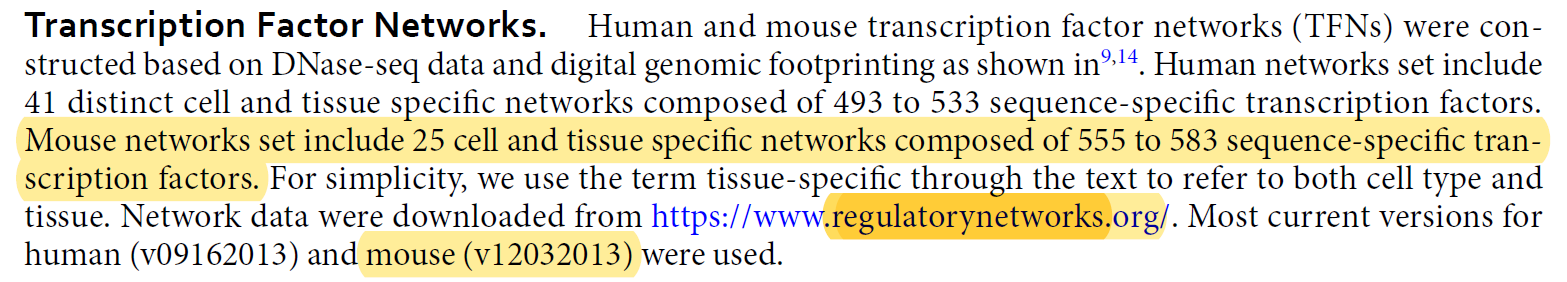

#### Fxn para extraer nombres

In [2]:
def get_mouse_names(root, code_names):
    name = re.split('mouse_net', root)
    name = name[1]
    name = name.replace('\\','')
    return code_names[name]

#### Fxn para extraer redes

In [3]:
def extract_networks(directory_name=str, files_ignore=list, cols=tuple, feo=True, code_names=dict):
    networks = {}
    for root, dir, files in os.walk(directory_name):
        if len(files) != 0 and files[0] not in files_ignore:
          path = os.path.join(os.getcwd(), root, files[0])
          net = RegNet()
          if feo:
               f = np.genfromtxt(path, dtype= str, delimiter='\t', usecols= cols)
               net.add_edges_from(f)
          else:
               net = nx.read_edgelist(path)
          name = get_mouse_names(root, code_names)
          networks[name] = net
    return networks

#### Obtención de redes

In [4]:
mm9CellTypeValues = { "m3134-DS8497" : 			  "mammary adenocarcinoma",
                        "m416B-DS14099" : 		  "CD34+ myeloid progenitor",
                        "mA20-DS16695" :            "B-lymphocyte reticulum cell sarcoma",
                        "mATn-DS17070" :            "activated T-naive cell",
                        "mATr-DS20149" :            "ATr",
                        "mB-DS16168" :              "B-cell, replicate 1",
                        "mB-DS17866" :              "B-cell, replicate 2",
                        "mBrain-DS12727" :          "normal brain",
                        "mCJ7-DS13320" :            "embryonic stem cells via 129S1/SVImJ mice",
                        "MEL-DS13036" :             "leukemia, K562 analog",
                        "mfBrain-DS14536" :         "fetal brain",
                        "mGenitalFatPad-DS18182" :  "genital adipose tissue",
                        "mHeart-DS18138" :          "normal heart",
                        "mKidney-DS13948" :         "normal kidney",
                        "mLiver-DS14605" :          "normal liver",
                        "mLung-DS14479" :           "normal lung",
                        "mNIH_3T3-DS16900" :        "fibroblast",
                        "mRetina-DS20004" :         "normal retina", 
                        "mThymus-DS18819" :         "normal thymus",
                        "mTN-DS16171" :             "TN, replicate 1",
                        "mTN-DS17080" :             "TN, replicate 2",
                        "mTR-DS17864" :             "regulatory T-cells",
                        "ZhBTc4-DS15236" :          "embryonic stem cells, +6 hrs doxycycline",
                        "ZhBTc4-DS17562" :          "embryonic stem cells, +24 hrs doxycycline",
                        "ZhBTc4-DS17616" :          "embryonic stem cells, control"
                        }

mouse_networks = extract_networks('mouse_net', [], (3,4), feo=True, code_names=mm9CellTypeValues)

In [5]:
nets_info = {'Cell Type': [],
        'Nodes': [],
        'Edges': [],
        'Density': []
        }

for name,G in mouse_networks.items():
    n_nodes = G.number_of_nodes()
    n_edges = G.number_of_edges()
    density = n_edges / (n_nodes * (n_nodes - 1))
    nets_info['Cell Type'].append(name)
    nets_info['Nodes'].append(n_nodes)
    nets_info['Edges'].append(n_edges)
    nets_info['Density'].append(density)

In [6]:
info_df = pd.DataFrame.from_dict(nets_info)

In [7]:
info_df

,Cell Type,Nodes,Edges,Density
0,mammary adenocarcinoma,568,21059,0.065389
1,CD34+ myeloid progenitor,570,17263,0.053227
2,B-lymphocyte reticulum cell sarcoma,571,19197,0.058982
3,activated T-naive cell,579,26089,0.077956
4,ATr,575,20060,0.060779
5,"B-cell, replicate 1",574,20775,0.063165
6,"B-cell, replicate 2",555,14721,0.047878
7,normal brain,562,14768,0.046841
8,embryonic stem cells via 129S1/SVImJ mice,579,19420,0.058029
9,"leukemia, K562 analog",568,19254,0.059785


In [8]:
info_df.describe()

,Nodes,Edges,Density
count,25.000000,25.000000,25.000000
mean,574.440000,21567.760000,0.065228
std,7.211565,4632.396637,0.012716
min,555.000000,14626.000000,0.045255
25%,569.000000,19197.000000,0.058982
50%,575.000000,20775.000000,0.062737
75%,581.000000,25377.000000,0.075619
max,583.000000,33330.000000,0.098230


### Netective imports

In [9]:
from netective import properties

from netective.utils import compute_moments

### Determino objetos propiedades

In [10]:
parent_class = properties._Property

In [11]:
def flatten_list_of_iterables(lst):
    return list(chain.from_iterable(lst))

def get_child_classes(parent_class):
    child_classes = []
    for name, obj in inspect.getmembers(properties):
        if (
            inspect.isclass(obj)
            and issubclass(obj, parent_class)
            and obj != parent_class
        ):
            child_classes.append(obj)
    return child_classes

child_classes = get_child_classes(parent_class)

def get_instances(G, child_classes):
    instances = {x.__name__: x(G) for x in child_classes}
    return instances

def normalize_props(instances, G, norm=None):
    norm_scalar_values = {}
    norm_dist_values = {}
    for name, x in instances.items():
        dict_ = (
            norm_scalar_values
            if x._return_type == "scalar"
            else norm_dist_values
        )
        try:
            if norm == "network":
                dict_[name] = x.norm_network()
            elif norm == "biological":
                dict_[name] = x.norm_biol()
        except (NotImplementedError, properties.NormalizationError):
            dict_[name] = np.nan

    return norm_scalar_values, norm_dist_values

def get_props(G, norm="network"):
    instances = get_instances(G, child_classes)
    scalar_values = {
        name: x.compute()
        for name, x in instances.items()
        if x._return_type == "scalar"
    }
    dist_values = {
        name: x.compute()
        for name, x in instances.items()
        if x._return_type == "distribution"
    }

    if norm is not None:
        scalar_values, dist_values = normalize_props(instances, G, norm=norm)

    dist_values = {
        k: v for k, v in dist_values.items() if not np.isnan(v).all()
    }
    scalar_values = {k: v for k, v in scalar_values.items() if not np.isnan(v)}

    return scalar_values, dist_values

### Ploteos

In [12]:
def plot_distributions(dist_values):

    # Determine the grid shape based on the number of items
    num_items = len(dist_values)
    grid_shape = (
        int(np.sqrt(num_items)) + 1,
        int(np.ceil(np.sqrt(num_items))) + 1,
    )

    # Create the figure and subplots
    fig, axs = plt.subplots(
        nrows=grid_shape[0],
        ncols=grid_shape[1],
        figsize=(3 * grid_shape[0], 1.5 * grid_shape[1]),
    )

    # Flatten the axes array if it's more than 1D
    if num_items > 1:
        axs = axs.flatten()

    # Iterate over the dictionary items and create the subplots
    for i, (title, data) in enumerate(dist_values.items()):
        ax = (
            axs[i] if num_items > 1 else axs
        )  # Use a single axis if there's only one item
        sns.kdeplot(data, ax=ax, fill=True, color="#384265")
        ax.set_title(title)

    # Remove any extra empty subplots
    if num_items < axs.size:
        for j in range(num_items, axs.size):
            fig.delaxes(axs[j])

    # Adjust spacing between subplots
    fig.tight_layout()

    return fig, axs


def plot_scalars(data_dict):
    # Extract keys (strings) and values (floats) from the dictionary
    labels = list(data_dict.keys())
    values = list(data_dict.values())

    with sns.axes_style("darkgrid"):
        # Create the figure and axes
        fig, axs = plt.subplots(figsize=(2, 0.3 * len(labels)))

        # Create a horizontal bar plot using seaborn
        sns.barplot(x=values, y=labels, ax=axs, color="#384265")

        # Add annotations to the bars
        for i, value in enumerate(values):
            if isinstance(value, float):
                if value.is_integer():
                    value = int(value)
                else:
                    value = round(value, 2) if value >= 0.01 else value
            plt.text(
                value,
                i,
                str(value) if value >= 0.01 else f"{value:.2E}",
                va="center",
            )

        # Customize the plot
        axs.set_xlabel("Values")
        axs.set_ylabel("")

    return fig, axs

def create_symmetric_heatmap(dataframe, title: str):
    # Create a figure and axes
    # fig, axs = plt.subplots()

    # Plot the heatmap
    g = sns.clustermap(
        dataframe.astype(float),
        cmap="Blues",
        vmin=0,
        vmax=1,
        annot=True,
        fmt=".2f",
        cbar=True,
    )

    # Set the title
    g.ax_heatmap.set_title(title)

    # Return the figure and axes
    return g.fig, g.ax_heatmap

### Comps

In [13]:
def pairwise_pearson_correlation(
    dict_data,
):  # TODO: make this general for any correlation... # shouldn't be here...
    # Get the keys (name_dists) from the dictionary
    name_dists = list(dict_data.keys())

    # Initialize an empty DataFrame to store the correlation coefficients
    corr_df = pd.DataFrame(index=name_dists, columns=name_dists)

    # Calculate the pairwise Pearson correlation coefficients
    for i in range(len(name_dists)):
        for j in range(i, len(name_dists)):
            name_dist1 = name_dists[i]
            name_dist2 = name_dists[j]
            array1 = dict_data[name_dist1]
            array2 = dict_data[name_dist2]

            filtered_array1 = array1[np.isfinite(array1)]
            filtered_array2 = array2[np.isfinite(array2)]

            # Calculate Pearson correlation coefficient and p-value
            corr_coef, _ = pearsonr(
                filtered_array1, filtered_array2
            )  # TODO!!! genera error por nan o inf. Debes filtrar antes de calcular la correlación, en todos los vectores a comparar.
            print(name_dist1, name_dist2, array1, array2, corr_coef)

            # Store the correlation coefficient in the DataFrame
            corr_df.loc[name_dist1, name_dist2] = corr_coef
            corr_df.loc[name_dist2, name_dist1] = corr_coef

    return corr_df

### Main Fxns

#### Una sola red

In [14]:
def main_single(G, norm="network"):
    scalar_values, dist_values = get_props(G, norm=norm)

    fig_dist, _ = plot_distributions(dist_values)
    fig_scalar, _ = plot_scalars(scalar_values)

    fig_scalar.show()
    fig_dist.show()

#### Más de una red

In [35]:
def main_multiple(networks, norm=None):
    # Iterate over the uploaded files and perform the necessary operations
    start = time.perf_counter_ns()
    scalar_arrays = {}
    dist_moments_arrays = {}
    for name, G in networks.items():
        # props
        scalar_values, dist_values = get_props(G, norm=norm)
        # scalar properties
        scalar_arrays[name] = np.asarray(
            list(scalar_values.values())
        )
        dist_moments = [
            compute_moments(array) for array in dist_values.values()
        ]
        dist_moments_arrays[name] = np.asarray(
            flatten_list_of_iterables(dist_moments)
        )
        print(dist_moments_arrays[name])

    props_end = time.perf_counter_ns() - start
    print(f'Tiempo de cálculo de propiedades: {props_end/(6e+10)}min')
    df = pairwise_pearson_correlation(scalar_arrays)
    comp_end_scalar = time.perf_counter_ns() - props_end - start
    print(f'Tiempo de comparación: {comp_end_scalar/(6e+10)}min')
    fig_scalar, _ = create_symmetric_heatmap(
        df, title=f"Network-level properties"
    )
    # distribution properties
    df = pairwise_pearson_correlation(dist_moments_arrays)
    comp_end_dist = time.perf_counter_ns() - props_end - comp_end_scalar -start
    print(f'Tiempo de comparación: {comp_end_dist/6e+10}min')
    fig_dist, _ = create_symmetric_heatmap(df, title=f"Node-level properties")

    
    fig_scalar.show()
    fig_dist.show()

### Main
    aguas

#### Prep

In [16]:
selected_nets = ['normal brain', 'embryonic stem cells, +6 hrs doxycycline', 'embryonic stem cells, control', 'normal thymus']

In [26]:
prueba_single = ['embryonic stem cells, +6 hrs doxycycline']

In [30]:
prueba = {name : value for i, (name, value) in enumerate(mouse_networks.items()) if name in selected_nets}

In [31]:
ER = nx.erdos_renyi_graph(n=574, p=0.07, directed=True)
ER_RegNet = RegNet(ER)
prueba['ER'] = ER_RegNet

In [36]:
prueba

{'normal brain': <freyrelab.regnets.regnet.RegNet at 0x1d67052f5b0>,
 'normal thymus': <freyrelab.regnets.regnet.RegNet at 0x1d67052f8e0>,
 'embryonic stem cells, +6 hrs doxycycline': <freyrelab.regnets.regnet.RegNet at 0x1d67052fd00>,
 'embryonic stem cells, control': <freyrelab.regnets.regnet.RegNet at 0x1d670562fd0>,
 'ER': <freyrelab.regnets.regnet.RegNet at 0x1d60f848190>}

#### Prueba con multiples

[ 2.13722811e-001  3.62644995e-003  8.57977695e-001  2.50288037e+000
  5.46082971e-002  1.43785601e-003 -3.89803866e-001 -1.05397487e+000
  2.09619597e-003  2.17331591e-005  4.48771719e+000  2.66285747e+001
  3.61810010e-001  3.69893366e-002  2.40656826e-001  1.19093525e+000
  5.76626639e-003  5.83355955e-007  1.18260400e+000 -3.93052092e-001
  4.93439799e-002  6.31561602e-003  2.94299369e+000  9.59228442e+000
  1.03785924e-001  1.51045760e-002  2.11603133e+000  5.58662358e+000
  4.93439799e-002  2.93914377e-003  1.08010197e+000  6.94130562e-001
  9.16675927e-200  0.00000000e+000              nan              nan]
[ 2.26889087e-001  2.81676141e-003  1.44968356e+000  7.80262245e+000
  5.36650444e-002  1.92165824e-003  1.13282119e-001 -5.31499249e-001
  1.93227375e-003  1.44213107e-005  3.87407633e+000  2.17533477e+001
  3.67880920e-001  2.97127488e-002  4.08354086e-001  2.34336508e+000
  6.02069205e-003  7.77757141e-007  4.34928722e-001 -1.59358329e+000
  5.69765424e-002  6.63823233e-00

C:\Users\PepeS\AppData\Local\Temp\ipykernel_16232\3483106216.py:36: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig_scalar.show()
C:\Users\PepeS\AppData\Local\Temp\ipykernel_16232\3483106216.py:37: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig_dist.show()


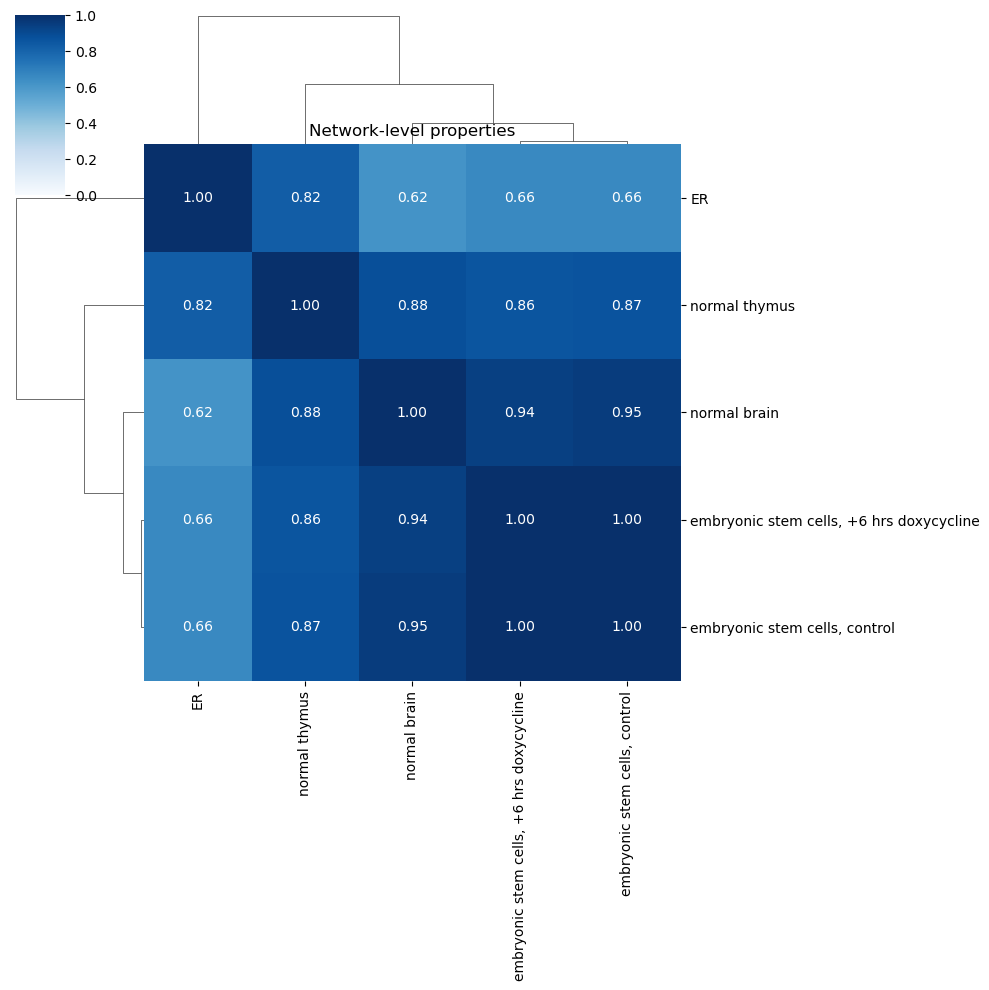

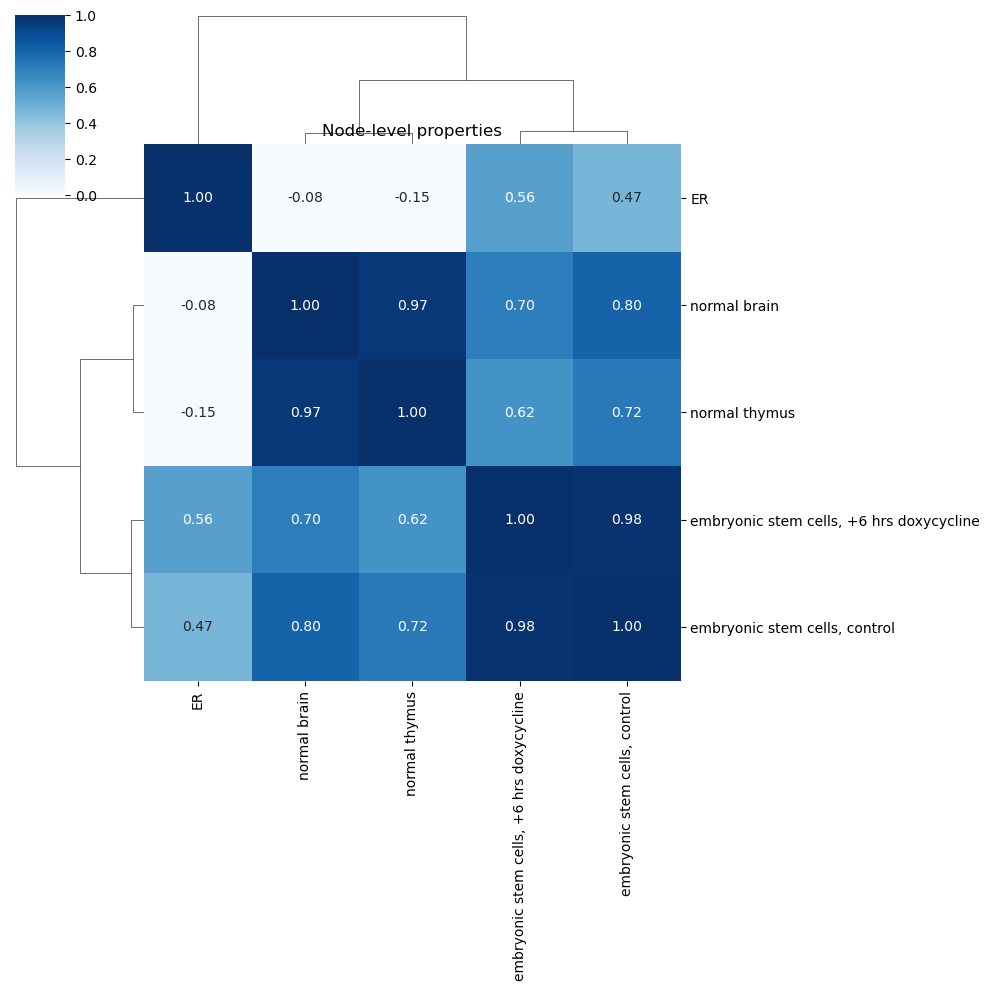

In [37]:
main_multiple(prueba, norm='network')

#### Prueba con individuales

C:\Users\PepeS\AppData\Local\Temp\ipykernel_16232\2723621231.py:26: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data, ax=ax, fill=True, color="#384265")
C:\Users\PepeS\AppData\Local\Temp\ipykernel_16232\273552238.py:7: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig_scalar.show()
C:\Users\PepeS\AppData\Local\Temp\ipykernel_16232\273552238.py:8: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig_dist.show()


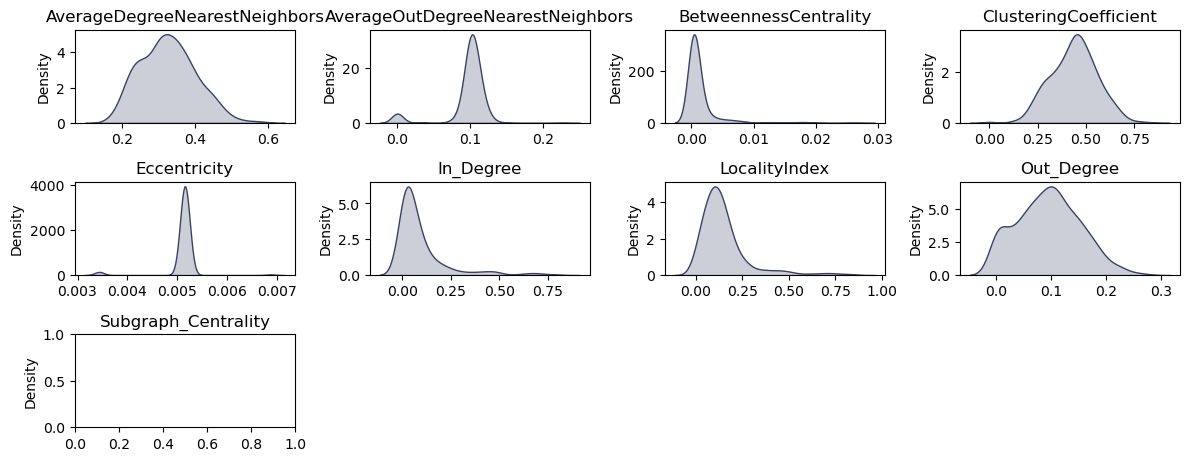

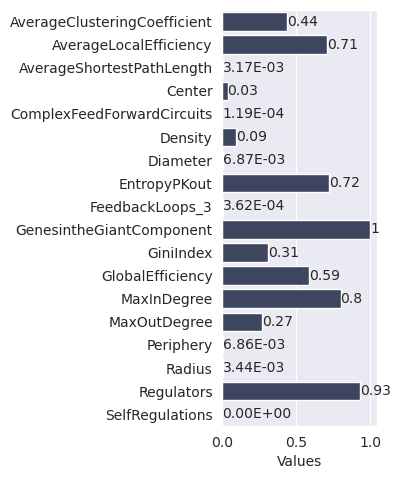

In [29]:
main_single(prueba['embryonic stem cells, +6 hrs doxycycline'], norm='network')

C:\Users\PepeS\AppData\Local\Temp\ipykernel_16232\2723621231.py:26: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data, ax=ax, fill=True, color="#384265")
C:\Users\PepeS\AppData\Local\Temp\ipykernel_16232\273552238.py:7: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig_scalar.show()
C:\Users\PepeS\AppData\Local\Temp\ipykernel_16232\273552238.py:8: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig_dist.show()


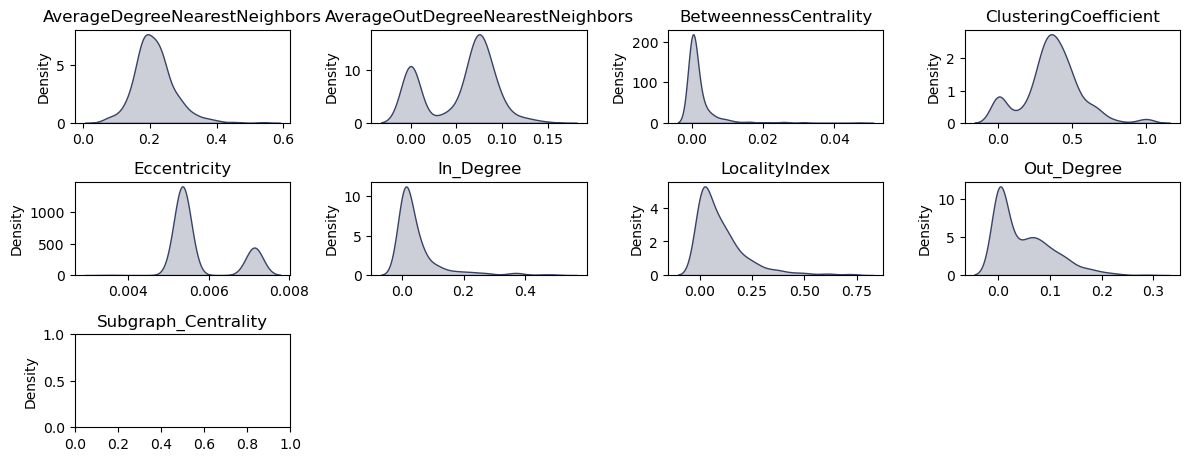

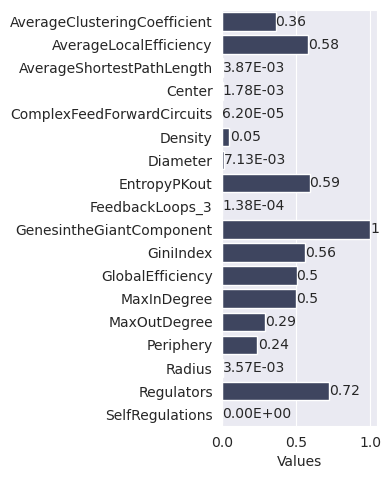

In [25]:
main_single(prueba['normal brain'], norm='network')